In [15]:
import pandas as pd
import numpy as np
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
c_to_i =  {'ACC': 0, 'BLCA': 1, 'BRCA': 2, 'CESC': 3, 'CHOL': 4, 'CNTL': 5, 'COAD': 6, 'DLBC': 7, 'ESCA': 8, 'FPPP': 9, 'GBM': 10, 'HNSC': 11, 'KICH': 12, 'KIRC': 13, 'KIRP': 14, 'LAML': 15, 'LCML': 16, 'LGG': 17, 'LIHC': 18, 'LUAD': 19, 'LUSC': 20, 'MESO': 21, 'MISC': 22, 'OV': 23, 'PAAD': 24, 'PCPG': 25, 'PRAD': 26, 'READ': 27, 'SARC': 28, 'SKCM': 29, 'STAD': 30, 'TGCT': 31, 'THCA': 32, 'THYM': 33, 'UCEC': 34, 'UCS': 35, 'UVM': 36}

i_to_c = {v: k for k, v in c_to_i.items()}
models = {}
model_idx = 1

In [ ]:
all_results = defaultdict(list)
all_results_2 = defaultdict(list)


for gen_image in ['genetics_and_image', 'only_genetics', "only_image"]:
    for batch in ['ct_batch', 'all_batch']:
        for exp in ['cancertypebatching_exp_0_warmup_0', 'cancertypebatching_exp_1_warmup_10', 'cancertypebatching_exp_0_phase2_10', 'cancertypebatching_exp_1_phase2_0']:
            
            path = f"/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)
                all_results_2['model'].append(model_idx)

                models[model_idx] = f"{gen_image}_{batch}_{exp}"
                model_idx += 1


                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)

                    all_results_2[i_to_c[cancer]].append(c_idx)

            except:
                pass

In [18]:
all_results_2

defaultdict(list,
            {'model': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
             'ESCA': [0.5434951960529733,
              0.5862113736691769,
              0.5010328936914031,
              0.5483870967741935,
              0.5164892235782913,
              0.5264866268501688,
              0.4981822903142041,
              0.4726045183069333,
              0.487405868605557,
              0.5253180991950143,
              0.4635159698779538,
              0.5122046221760582],
             'BRCA': [0.5373081042484826,
              0.5784212405343956,
              0.5328149091640411,
              0.6127907756251257,
              0.5276780848944925,
              0.4975384731017118,
              0.5531483116931922,
              0.5215430579304384,
              0.5713936751911911,
              0.6298690317367858,
              0.6199101824536349,
              0.6274075048384975],
             'GBM': [0.5203185370156411,
              0.498639633260035,
            

In [19]:
df = pd.DataFrame(all_results_2).T

df.to_csv("./test_df_2.csv")

In [21]:
models

{1: 'genetics_and_image_ct_batch_cancertypebatching_exp_0_warmup_0',
 2: 'genetics_and_image_ct_batch_cancertypebatching_exp_1_warmup_10',
 3: 'genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10',
 4: 'genetics_and_image_all_batch_cancertypebatching_exp_1_phase2_0',
 5: 'only_genetics_ct_batch_cancertypebatching_exp_0_warmup_0',
 6: 'only_genetics_ct_batch_cancertypebatching_exp_1_warmup_10',
 7: 'only_genetics_all_batch_cancertypebatching_exp_0_phase2_10',
 8: 'only_genetics_all_batch_cancertypebatching_exp_1_phase2_0',
 9: 'only_image_ct_batch_cancertypebatching_exp_0_warmup_0',
 10: 'only_image_ct_batch_cancertypebatching_exp_1_warmup_10',
 11: 'only_image_all_batch_cancertypebatching_exp_0_phase2_10',
 12: 'only_image_all_batch_cancertypebatching_exp_1_phase2_0'}

/tmp/ipykernel_16988/1975403546.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


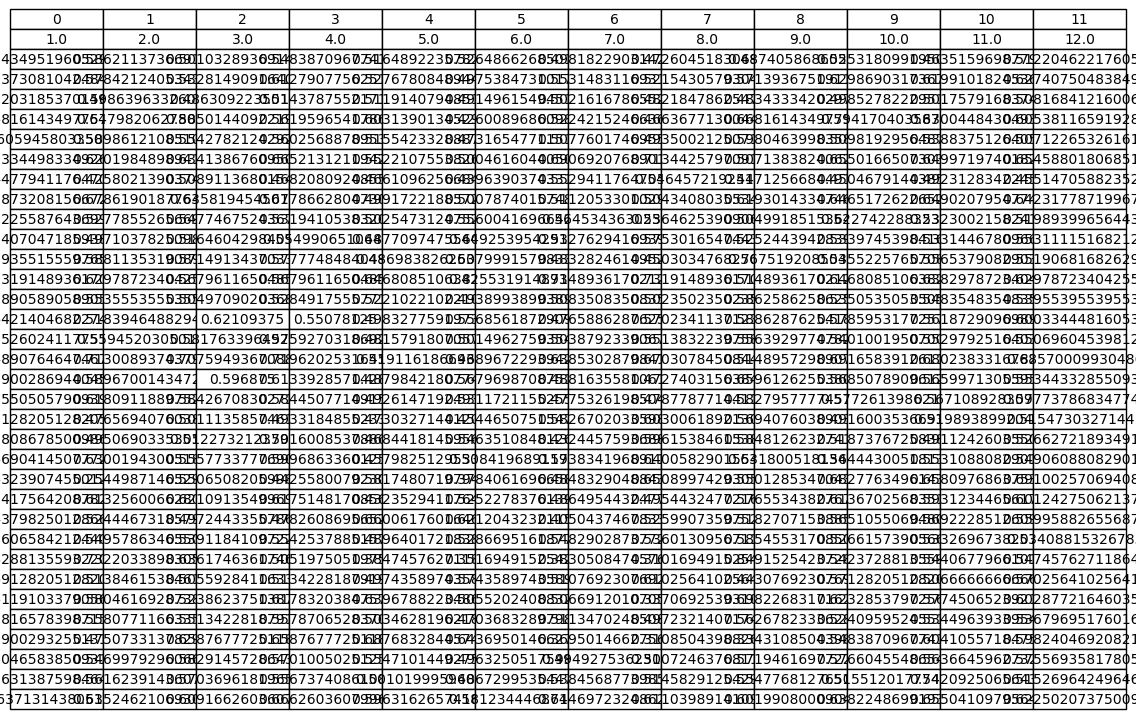

In [22]:
# Create a matplotlib table
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.tight_layout()

plt.show()

/tmp/ipykernel_16988/4224187853.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


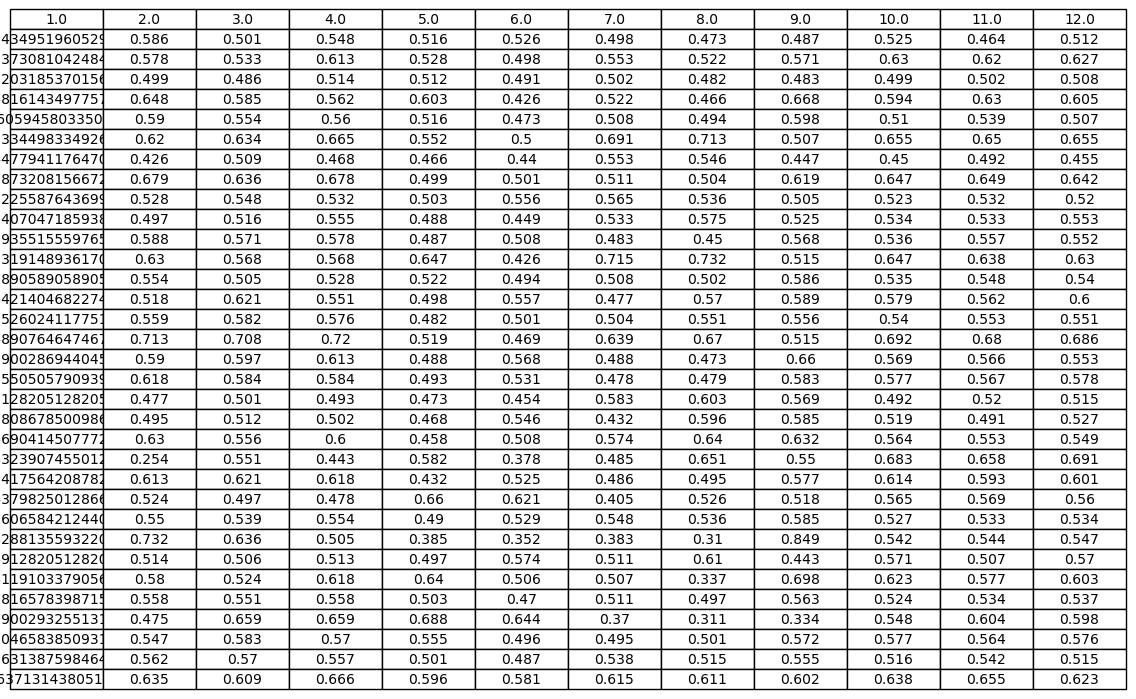

In [23]:
# Round all values (except the 'model' column) to 3 decimal places
df_rounded = df.copy()
df_rounded.iloc[:, 1:] = df_rounded.iloc[:, 1:].round(3)

# Create a matplotlib table without the header row
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(cellText=df_rounded.values, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.tight_layout()

plt.show()
